# Numpy Array vs Python List

In [3]:
# speed
a=[i for i in range(10000000)]
b=[i for i in range(10000000,20000000)]

c=[]

import time 
start = time.time()
for i in range(len(a)):
    c.append(a[i] + b[i])
end=time.time() - start
print(end)

2.876556396484375


In [ ]:
import numpy as np
a=np.arange(10000000)
b=np.arange(10000000,20000000)  # time taken by the numpy
start=time.time()
add=a+b
end=time.time() - start
print(end)

0.025391578674316406


In [ ]:
# how much time is faster?
2.876556396484375/0.025391578674316406


113.28781220657277

In [6]:
# now in term of the memory size occupation
a=[i for i in range(10000000)]
import sys
sys.getsizeof(a)

89095160

In [17]:
b=np.arange(10000000,dtype=np.int8)
import sys
sys.getsizeof(b)

10000112

In [18]:
c=np.arange(10000000,dtype=np.int16)
import sys
sys.getsizeof(c)

20000112

In [11]:
a=np.arange(10000000,dtype=np.int32)
import sys
sys.getsizeof(a)

40000112

In [19]:
d=np.arange(10000000,dtype=np.int64) # approx equal but others takes the minimum
import sys
sys.getsizeof(d)

80000112

In [20]:
print(b[-5:]) # Look at the last 5 elements

[123 124 125 126 127]


In [21]:
print(b.dtype)


int8


## Fancy Indexcing

In [2]:
# let take a 2d array
import numpy as np
arry=np.arange(1,13).reshape(3,4)
arry

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [ ]:
arry[[1,2]] # mean i need 2nd and 3rd row complete

array([[ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [4]:
array1=np.arange(36).reshape(6,6)
array1

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11],
       [12, 13, 14, 15, 16, 17],
       [18, 19, 20, 21, 22, 23],
       [24, 25, 26, 27, 28, 29],
       [30, 31, 32, 33, 34, 35]])

In [ ]:
# now i want to get the 1, 4, 5 index row
array1[[1,4,5]]

array([[ 6,  7,  8,  9, 10, 11],
       [24, 25, 26, 27, 28, 29],
       [30, 31, 32, 33, 34, 35]])

In [6]:
# now want to get the 2nd, 4th and 5th column
array1[:,[1,3,4]]

array([[ 1,  3,  4],
       [ 7,  9, 10],
       [13, 15, 16],
       [19, 21, 22],
       [25, 27, 28],
       [31, 33, 34]])

In [7]:
array1[[1,3,4],[1,3,4]]

array([ 7, 21, 28])

In [ ]:
print(array1[[5],[5]]) # if i just need 35

[35]


In [10]:
array2=np.arange(64).reshape(4,4,4)
array2

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15]],

       [[16, 17, 18, 19],
        [20, 21, 22, 23],
        [24, 25, 26, 27],
        [28, 29, 30, 31]],

       [[32, 33, 34, 35],
        [36, 37, 38, 39],
        [40, 41, 42, 43],
        [44, 45, 46, 47]],

       [[48, 49, 50, 51],
        [52, 53, 54, 55],
        [56, 57, 58, 59],
        [60, 61, 62, 63]]])

In [ ]:
array2[2] # this is the layer2 ok

array([[32, 33, 34, 35],
       [36, 37, 38, 39],
       [40, 41, 42, 43],
       [44, 45, 46, 47]])

In [16]:
# now i just want the 42,43 and 46,47 from layer 2
array2[2,2:,2:]

array([[42, 43],
       [46, 47]])

# Boolean Indexing

In [2]:
# creating the number from 1 to 100 and given the total input how much numbers we want
import numpy as np
a=np.random.randint(1,100,24).reshape(6,4)
a

array([[98,  8, 72, 10],
       [13, 68,  3, 55],
       [18,  8,  9, 36],
       [93, 77, 17, 64],
       [ 1, 81, 89, 44],
       [26, 90, 98, 39]], dtype=int32)

In [4]:
# 01: find all the numbers greater than 50
# now am going to apply the boolean masking ok
# first just see the a>50
a>50

array([[ True, False,  True, False],
       [False,  True, False,  True],
       [False, False, False, False],
       [ True,  True, False,  True],
       [False,  True,  True, False],
       [False,  True,  True, False]])

In [ ]:
# Now apply the boolean masking
a[a>50] # it will just show where the value is true ok

array([98, 72, 68, 55, 93, 77, 64, 81, 89, 90, 98], dtype=int32)

In [9]:
# 02: Greater then 50 and should be even 
a[(a>50) & (a%2==0)]

array([98, 72, 68, 64, 90, 98], dtype=int32)

In [10]:
# numbers not divible by the 6
a[a % 6 !=0]

array([98,  8, 10, 13, 68,  3, 55,  8,  9, 93, 77, 17, 64,  1, 81, 89, 44,
       26, 98, 39], dtype=int32)

## Broadcasting

"The term broadcasting describes how NumPy treats arrays with different shapes during arithmetic operations.

The smaller array is "broadcast" across the larger array so that they have compatible shapes.

# Same Shape

In [15]:
# take the same shape two array
a=np.arange(6).reshape(2,3)
b=np.arange(6,12).reshape(2,3)
print(a)
print()
print(b)
#  now let try to add them
print(f"Result of Addition:\n{a+b}")

[[0 1 2]
 [3 4 5]]

[[ 6  7  8]
 [ 9 10 11]]
Result of Addition:
[[ 6  8 10]
 [12 14 16]]


## Different Shape

In [20]:
# Take the same shape two array
a=np.arange(6).reshape(2,3)
b=np.arange(3).reshape(1,3)
print(a)
print()
print(b)
#  now let try to add them
print(f"Result of Addition:\n{a+b}")

[[0 1 2]
 [3 4 5]]

[[0 1 2]]
Result of Addition:
[[0 2 4]
 [3 5 7]]


## Broadcasting Rules

## 1 Make the two arrays have the same number of dimensions.

If the numbers of dimensions of the two arrays are different, add new dimensions with size 1 to the head of the array with the smaller dimension.

## 2 Make each dimension of the two arrays the same size.

If the sizes of each dimension of the two arrays do not match, dimensions with size 1 are stretched to the size of the other array.  

If there is a dimension whose size is not 1 in either of the two arrays, it cannot be broadcasted, and an error is raised.

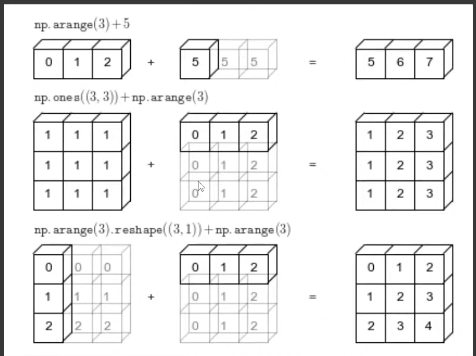